In [1]:
import torch
import matplotlib.pyplot as plt
g=torch.Generator().manual_seed(114514)

In [2]:
class Tanh:
    def __call__(self,x):
        self.out=torch.tanh(x)
        return self.out
    def parameters(self):
        return []

In [3]:
class Linear:
    def __init__(self,fan_in,fan_out,bias=True):
        self.weight=torch.randn((fan_in,fan_out),generator=g)/fan_in**0.5
        self.bias=torch.zeros(fan_out) if bias else None
    def __call__(self,X):
        self.out=X@self.weight
        if self.bias is not None:
            self.out+=self.bias
        return self.out
    def parameters(self):
        return [self.weight]+([]if self.bias is None else [self.bias])

        

In [4]:
class BatchNorm1d:
    def __init__(self,dim,eps=1e-5,momentum=0.1):
        self.eps=eps
        self.momentum=momentum
        self.training=True
        self.gamma=torch.ones(dim)
        self.beta=torch.zeros(dim)
        self.running_mean=torch.zeros(dim)
        self.running_var=torch.ones(dim)
    def __call__(self,x):
        if self.training:
            xmean=x.mean(0,keepdim=True)
            xvar=x.var(0,keepdim=True)
        else :
            xmean=self.running_mean
            xvar=self.running_var
        xstd=torch.sqrt(xvar+self.eps)
        xhat=(x-xmean)/xstd
        self.out=self.gamma*xhat+self.beta
        if self.training:
            with torch.no_grad():
                self.running_mean=(1-self.momentum)*self.running_mean+self.momentum*xmean
                self.running_var=(1-self.momentum)*self.running_var+self.momentum*xvar
        # 保存中间变量用于反向传播
        # 对beta的求导就是1 * dout 故不需要存贝塔的缓存,用不上
        self.cache=(x,xmean,xvar,xstd,xhat,self.gamma)
        return self.out
    def parameters(self):
        return [self.gamma,self.beta]
    
    def backward(self,dout):
        '''
        dout :上游梯度,形状为[B,D]
        返回 dx,形状BD
        '''
        x,xmean,xvar,xstd,xhat,gamma=self.cache
        B=x.shape[0]
        self.gamma.grad=(dout*xhat).sum(0)
        self.beta.grad=dout.sum(0)
        # xhat=(x-xmean)/sqrt(xvar+eps)
        dxhat=dout*gamma
        dx=dxhat/xstd
        dvar=dxhat*(x-xmean)*(-1/2)*((xvar+self.eps)**(-2/3)).sum(0,keepdim=True)
        dmean=-dxhat/xstd.sum(0,keepdim=True)+(dvar*(-2)*(x-xmean)/B).sum(0,keepdim=True)
        dx+=dvar*2*(x-xmean)/B 
        dx+=dmean/B

        return dx
    
        
        
        
        

In [5]:
words=open("names.txt","r").read().splitlines()   

stoi={s:ord(s)-ord('a')+1 for s in sorted(set(''.join(words)))}
stoi['.']=0
itos={i:s for s,i in stoi.items()}


vocab_size=27
block_size=3
n_emb=10
n_hidden=100
layers=[
    Linear(n_emb*block_size,n_hidden),Tanh(),
    Linear(n_hidden,n_hidden),Tanh(),
    Linear(n_hidden,n_hidden),Tanh(),
     Linear(n_hidden,n_hidden),Tanh(),
      Linear(n_hidden,n_hidden),Tanh(),
    Linear(n_hidden,vocab_size),
]


def build_dataset(words):
    X,Y=[],[]
    for w in words:
        context=[0]*block_size
        for ch in w+'.':
            ix=stoi[ch]
            X.append(context)
            Y.append(ix)
            context=context[1:]+[ix]
    X=torch.tensor(X)
    Y=torch.tensor(Y)
    return X,Y

X,Y=build_dataset(words)
n1=int(0.8*len(words))
n2=int(0.9*len(words))
Xtr,Ytr=build_dataset(words[:n1])
Xdev,Ydev=build_dataset(words[n1:n2])
Xte,Yte=build_dataset(words[n2:])

In [6]:
C=torch.randn((27,10),generator=g)

In [17]:
import torch.nn.functional  as F
max_steps=100000
batch_size=32
lossi=[]
ud=[] # update/data ratio

parameters=[p for layer in layers for p in layer.parameters()]+[C]
for p in parameters:
    p.requires_grad=True
for i in range(max_steps):
    ix=torch.randint(0,Xtr.shape[0],(batch_size,))
    Xb,Yb=Xtr[ix],Ytr[ix]
    emb=C[Xb]
    x=emb.view(emb.shape[0],-1)
    for layer in layers:
        x=layer(x)
    loss=F.cross_entropy(x,Yb)
    # backward
    for layer in layers:
        layer.out.retain_grad()
    
    for p in parameters:
        p.grad=None
    loss.backward()
    lr =0.1 if i<10000 else 0.01
    for p in parameters:
        p.data+=-lr*p.grad
    if i%1000 ==0:
        print(f'{i:7d}/{max_steps}:{loss.item():.4f}')
    lossi.append(loss.log10().item())

    with torch.no_grad():
        ud.append([((lr*p.grad).std() / p.data.std()).log10().item()  
                   for p in parameters]) 


      0/100000:2.6199
   1000/100000:2.4291
   2000/100000:1.9573
   3000/100000:2.3468
   4000/100000:1.9838
   5000/100000:2.0897
   6000/100000:2.3505
   7000/100000:2.4793
   8000/100000:2.1883
   9000/100000:2.3027
  10000/100000:2.0850
  11000/100000:2.4211
  12000/100000:2.3113
  13000/100000:2.1071
  14000/100000:2.3557
  15000/100000:2.0286
  16000/100000:1.6943
  17000/100000:2.3103
  18000/100000:1.9796
  19000/100000:1.8018
  20000/100000:2.0493
  21000/100000:1.8697
  22000/100000:1.8689
  23000/100000:2.0438
  24000/100000:2.1123
  25000/100000:1.9848
  26000/100000:2.1396
  27000/100000:1.6559
  28000/100000:1.8506
  29000/100000:2.0404
  30000/100000:1.8634
  31000/100000:2.1409
  32000/100000:1.9861
  33000/100000:2.1114
  34000/100000:1.9103
  35000/100000:1.8511
  36000/100000:1.9984
  37000/100000:2.0745
  38000/100000:1.7440
  39000/100000:1.9584
  40000/100000:2.2965
  41000/100000:2.0342
  42000/100000:2.0726
  43000/100000:1.9393
  44000/100000:1.8166
  45000/10

In [ ]:
def fold_bn_into_linear(linear:Linear,bn:BatchNorm1d):
    """
    将batchnorm层的参数折叠到相邻的Linear层中,推理(而不是训练)时节省算力
    args:
        linear: Linear
        bn: BatchNormal1d
    returns:
        折叠后的weight,bias

    """
    # h=wx+b
    # y=gamma*(h-u)/std+beta
    # std=sqrt(var**2+eps)
    # y=gamma*w/std*x+gamma*(b-u)/std+beta
    std=torch.sqrt(bn.running_var+bn.eps)
    new_weight=bn.gamma/std*linear.weight
    if linear.bias is not None:
        new_bias=bn.gamma*(linear.bias-bn.running_mean)/std+bn.beta
    else:
        new_bias=bn.gamma*(-bn.running_mean)/std+bn.beta
    return new_weight,new_bias

layer 1 (Tanh): mean -0.03, std 0.73, saturated: 14.91%
layer 3 (Tanh): mean +0.03, std 0.75, saturated: 18.12%
layer 5 (Tanh): mean -0.02, std 0.76, saturated: 18.50%
layer 7 (Tanh): mean -0.02, std 0.77, saturated: 20.47%
layer 9 (Tanh): mean -0.01, std 0.71, saturated: 14.41%


Text(0.5, 1.0, 'activation distribution')

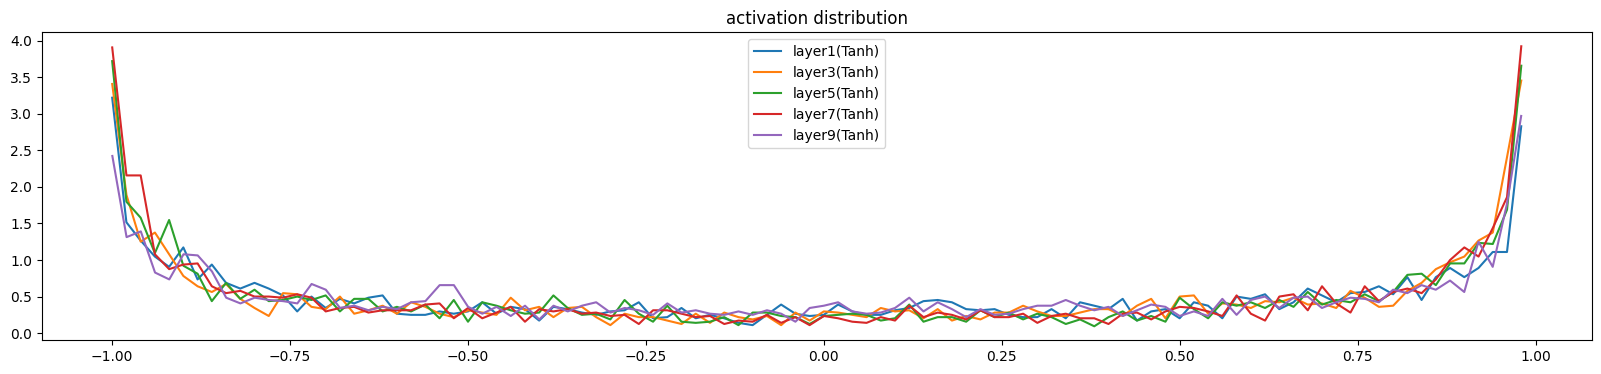

In [18]:
plt.figure(figsize=(20,4))
legends=[]
for i,layer in enumerate(layers[:-1]):
    if isinstance(layer,Tanh):
        t=layer.out
        print(f"layer {i} ({layer.__class__.__name__}): "
      f"mean {t.mean():+.2f}, std {t.std():.2f}, "
      f"saturated: {(t.abs() > 0.97).float().mean() * 100:.2f}%")
        hy,hx=torch.histogram(t,density=True)
        plt.plot(hx[:-1].detach(),hy.detach())
        legends.append(f'layer{i}({layer.__class__.__name__})')
plt.legend(legends)
plt.title('activation distribution')


layer 1 (Tanh): mean -0.03, std 0.73, saturated: 14.91%
layer 3 (Tanh): mean +0.03, std 0.75, saturated: 18.12%
layer 5 (Tanh): mean -0.02, std 0.76, saturated: 18.50%
layer 7 (Tanh): mean -0.02, std 0.77, saturated: 20.47%
layer 9 (Tanh): mean -0.01, std 0.71, saturated: 14.41%
可以清楚看到每一个tanh层的神经元分别死了15到20不等,这不是我们想要的